In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [9]:
# ── Load cleaned datasets ─────────────────────────────────────────────────────
benin        = pd.read_csv("../data/benin_clean.csv")
togo         = pd.read_csv("../data/togo_clean.csv")
sierra_leone = pd.read_csv("../data/SierraLeone_clean.csv")

# ── Tag each dataset with its country ────────────────────────────────────────
benin["Country"]        = "Benin"
togo["Country"]         = "Togo"
sierra_leone["Country"] = "Sierra Leone"

# ── Merge into one master dataframe ──────────────────────────────────────────
df_all = pd.concat([benin, togo, sierra_leone], ignore_index=True)

# ── Daytime filter (core protocol: GHI > 0 only) ─────────────────────────────
df_all = df_all[df_all["GHI"] > 0].reset_index(drop=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"Total rows (daytime only): {len(df_all):,}")
print(f"\nRows per country:")
print(df_all["Country"].value_counts())
print(f"\nColumns: {df_all.columns.tolist()}")

Total rows (daytime only): 797,772

Rows per country:
Country
Togo            267553
Benin           266390
Sierra Leone    263829
Name: count, dtype: int64

Columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'GHI_zscore', 'DNI_zscore', 'DHI_zscore', 'ModA_zscore', 'ModB_zscore', 'WS_zscore', 'WSgust_zscore', 'GHI_is_outlier', 'DNI_is_outlier', 'DHI_is_outlier', 'ModA_is_outlier', 'ModB_is_outlier', 'WS_is_outlier', 'WSgust_is_outlier', 'Hour', 'Month', 'Date', 'Country']


C:\Users\binia\AppData\Local\Temp\ipykernel_12304\1166257212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\binia\AppData\Local\Temp\ipykernel_12304\1166257212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\binia\AppData\Local\Temp\ipykernel_12304\1166257212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


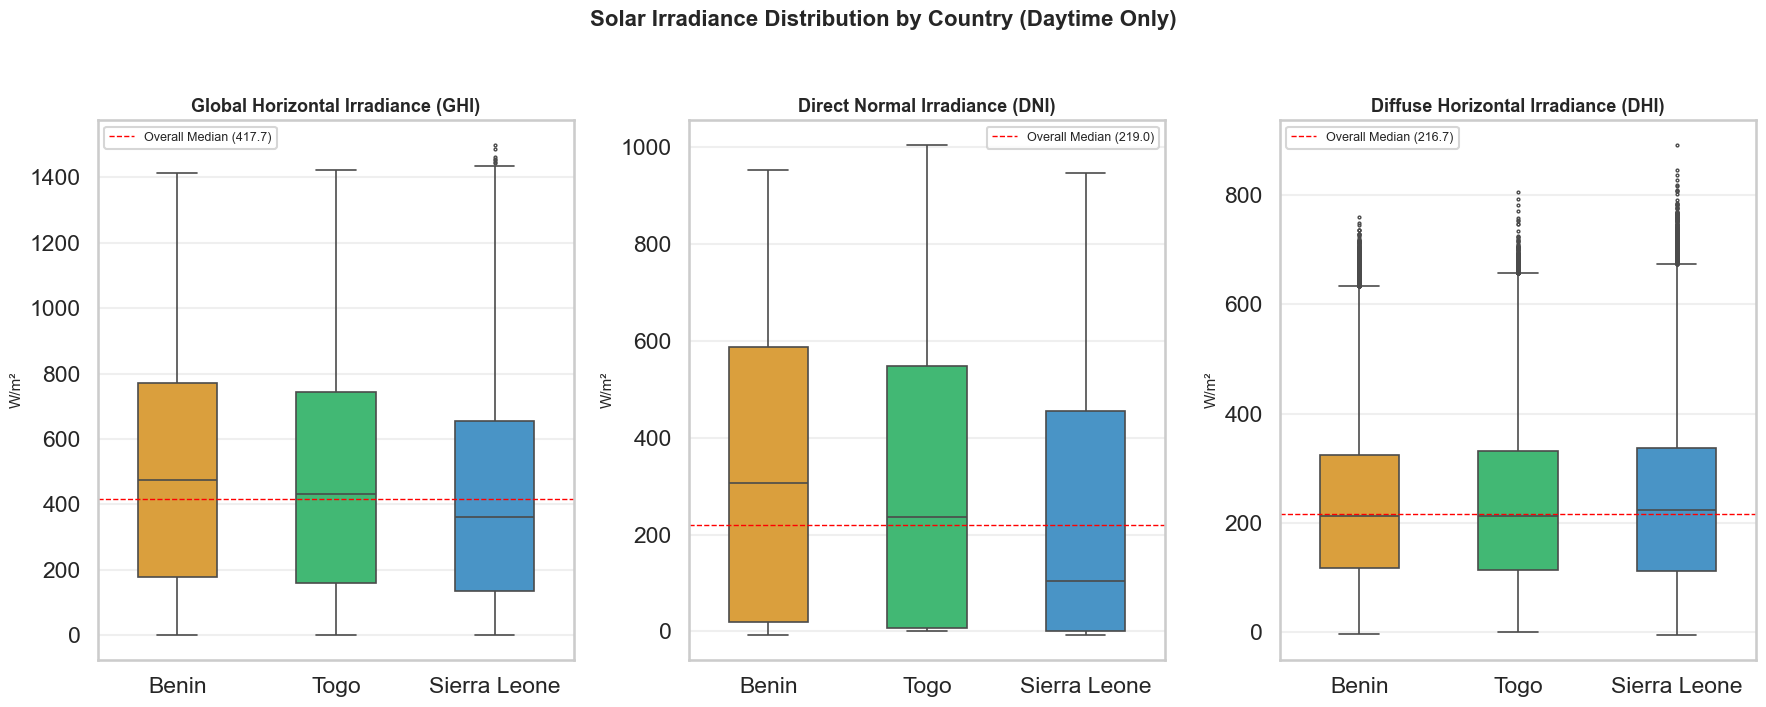

✓ Boxplots saved.


In [10]:
# ── Section 2: Boxplot Comparisons ───────────────────────────────────────────
import os; os.makedirs("outputs", exist_ok=True)

metrics     = ["GHI", "DNI", "DHI"]
titles      = {
    "GHI": "Global Horizontal Irradiance (GHI)",
    "DNI": "Direct Normal Irradiance (DNI)",
    "DHI": "Diffuse Horizontal Irradiance (DHI)"
}
country_order  = ["Benin", "Togo", "Sierra Leone"]
palette        = {"Benin": "#F4A623", "Togo": "#2ECC71", "Sierra Leone": "#3498DB"}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Solar Irradiance Distribution by Country (Daytime Only)",
             fontsize=16, fontweight="bold", y=1.02)

for ax, metric in zip(axes, metrics):
    sns.boxplot(
        data      = df_all,
        x         = "Country",
        y         = metric,
        order     = country_order,
        palette   = palette,
        width     = 0.5,
        fliersize = 2,        # small outlier dots — 1.6M rows = a lot of dots otherwise
        linewidth = 1.2,
        ax        = ax
    )

    # ── Reference line at median of all countries combined ───────────────────
    overall_median = df_all[metric].median()
    ax.axhline(overall_median, color="red", linestyle="--", linewidth=1,
               label=f"Overall Median ({overall_median:.1f})")

    ax.set_title(titles[metric], fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("W/m²", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/boxplots_irradiance_by_country.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Boxplots saved.")

In [11]:
# ── Section 3: Summary Statistics Table ──────────────────────────────────────

metrics = ["GHI", "DNI", "DHI"]

# ── Compute stats per country per metric ─────────────────────────────────────
rows = []
for country in ["Benin", "Togo", "Sierra Leone"]:
    df_c = df_all[df_all["Country"] == country]
    for metric in metrics:
        rows.append({
            "Country"  : country,
            "Metric"   : metric,
            "Mean"     : round(df_c[metric].mean(), 2),
            "Median"   : round(df_c[metric].median(), 2),
            "Std Dev"  : round(df_c[metric].std(), 2),
        })

summary_df = pd.DataFrame(rows)

# ── Pivot for clean display ───────────────────────────────────────────────────
summary_pivot = summary_df.pivot_table(
    index   = ["Country", "Metric"],
    values  = ["Mean", "Median", "Std Dev"],
    aggfunc = "first"
)[["Mean", "Median", "Std Dev"]]  # enforce column order

print("=" * 55)
print("   Solar Irradiance Summary Statistics (W/m²)")
print("=" * 55)
print(summary_pivot.to_string())
print("=" * 55)

# ── Save to CSV for reference ─────────────────────────────────────────────────
summary_pivot.to_csv("outputs/summary_statistics.csv")
print("✓ Summary table saved to outputs/summary_statistics.csv")

   Solar Irradiance Summary Statistics (W/m²)
                       Mean  Median  Std Dev
Country      Metric                         
Benin        DHI     230.83   213.4   150.48
             DNI     330.34   305.9   284.89
             GHI     477.40   475.1   320.31
Sierra Leone DHI     231.63   224.0   149.66
             DNI     232.11   104.8   261.44
             GHI     407.22   360.6   304.78
Togo         DHI     228.73   211.9   149.82
             DNI     297.14   235.3   283.50
             GHI     455.20   431.7   318.69
✓ Summary table saved to outputs/summary_statistics.csv


In [12]:
# ── Section 4: Kruskal-Wallis Statistical Test ────────────────────────────────

from scipy.stats import kruskal

metrics = ["GHI", "DNI", "DHI"]

# ── Separate each country's data ──────────────────────────────────────────────
benin_df        = df_all[df_all["Country"] == "Benin"]
togo_df         = df_all[df_all["Country"] == "Togo"]
sierraleone_df  = df_all[df_all["Country"] == "Sierra Leone"]

print("=" * 60)
print("   Kruskal-Wallis H-Test Results")
print("   H0: All countries have the same GHI/DNI/DHI distribution")
print("   H1: At least one country differs significantly")
print("=" * 60)

results = []
for metric in metrics:
    h_stat, p_value = kruskal(
        benin_df[metric].dropna(),
        togo_df[metric].dropna(),
        sierraleone_df[metric].dropna()
    )

    significance = "✓ SIGNIFICANT" if p_value < 0.05 else "✗ NOT SIGNIFICANT"

    print(f"\n  Metric  : {metric}")
    print(f"  H-stat  : {h_stat:,.2f}")
    print(f"  p-value : {p_value:.2e}")
    print(f"  Result  : {significance} (α = 0.05)")

    results.append({
        "Metric"       : metric,
        "H-Statistic"  : round(h_stat, 2),
        "p-value"      : f"{p_value:.2e}",
        "Significant"  : "Yes" if p_value < 0.05 else "No"
    })

print("\n" + "=" * 60)

# ── Save results ──────────────────────────────────────────────────────────────
kw_df = pd.DataFrame(results)
kw_df.to_csv("outputs/kruskal_wallis_results.csv", index=False)
print("✓ Kruskal-Wallis results saved to outputs/kruskal_wallis_results.csv")

   Kruskal-Wallis H-Test Results
   H0: All countries have the same GHI/DNI/DHI distribution
   H1: At least one country differs significantly

  Metric  : GHI
  H-stat  : 6,703.31
  p-value : 0.00e+00
  Result  : ✓ SIGNIFICANT (α = 0.05)

  Metric  : DNI
  H-stat  : 17,533.05
  p-value : 0.00e+00
  Result  : ✓ SIGNIFICANT (α = 0.05)

  Metric  : DHI
  H-stat  : 118.17
  p-value : 2.19e-26
  Result  : ✓ SIGNIFICANT (α = 0.05)

✓ Kruskal-Wallis results saved to outputs/kruskal_wallis_results.csv


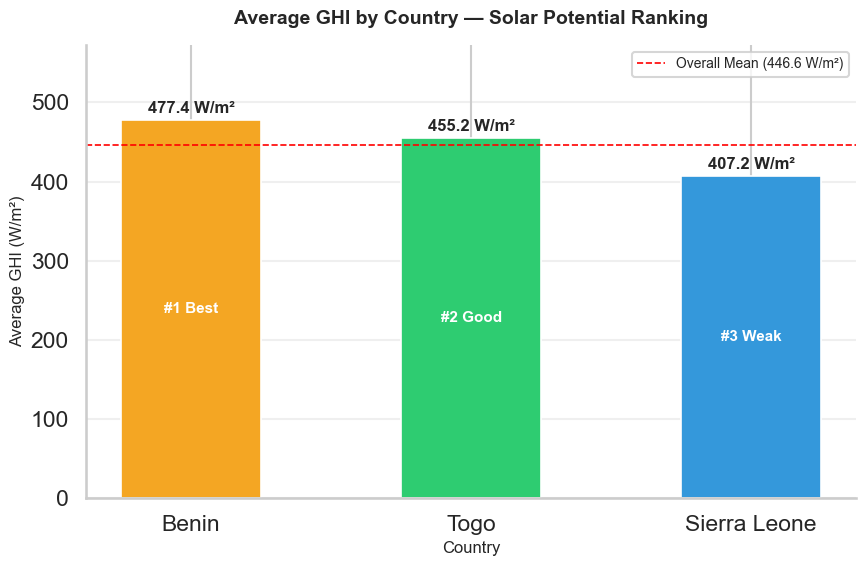

✓ Ranking chart saved to outputs/avg_ghi_ranking.png


In [14]:
# ── Section 5: Average GHI Bar Chart (Final Ranking) ─────────────────────────

# ── Compute average GHI per country ──────────────────────────────────────────
avg_ghi = (df_all.groupby("Country")["GHI"]
                 .mean()
                 .reindex(["Benin", "Togo", "Sierra Leone"]))  # enforce ranking order

colors      = ["#F4A623", "#2ECC71", "#3498DB"]  # consistent with boxplot palette
bar_labels  = [f"{v:.1f} W/m²" for v in avg_ghi.values]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    avg_ghi.index,
    avg_ghi.values,
    color     = colors,
    width     = 0.5,
    edgecolor = "white",
    linewidth = 1.2
)

# ── Value labels on top of each bar ──────────────────────────────────────────
for bar, label in zip(bars, bar_labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        label,
        ha         = "center",
        va         = "bottom",
        fontsize   = 12,
        fontweight = "bold"
    )

# ── Rank badges inside each bar ───────────────────────────────────────────────
ranks = ["#1 Best", "#2 Good", "#3 Weak"]
for bar, rank in zip(bars, ranks):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        rank,
        ha         = "center",
        va         = "center",
        fontsize   = 11,
        fontweight = "bold",
        color      = "white"
    )

# ── Reference line at overall mean ───────────────────────────────────────────
overall_mean = avg_ghi.mean()
ax.axhline(overall_mean, color="red", linestyle="--", linewidth=1.2,
           label=f"Overall Mean ({overall_mean:.1f} W/m²)")

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_title("Average GHI by Country — Solar Potential Ranking",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Average GHI (W/m²)", fontsize=12)
ax.set_ylim(0, avg_ghi.max() * 1.2)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/avg_ghi_ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Ranking chart saved to outputs/avg_ghi_ranking.png")

# 🔍 Key Observations & Investment Recommendations
---

## 1. Benin Has the Highest Solar Potential
Based on average GHI (**477.40 W/m²**), Benin ranks **#1** across all three countries.
Its median GHI (475.1 W/m²) is nearly equal to its mean — indicating a **stable, consistent**
solar resource with low skew. The Kruskal-Wallis test confirmed these differences are
statistically significant (H = 6,703, p ≈ 0). **Recommendation: Strong Invest.**

---

## 2. Togo Is Competitive But Has a Hardware Problem
Togo ranks **#2** on GHI (mean: 455.20 W/m²), close behind Benin.
However, its DNI median (235.3 W/m²) is significantly lower than Benin's (305.9 W/m²),
largely due to **46,716 zero-value DNI readings during daylight hours**, diagnosed as
mechanical tracker failure. The DNI Kruskal-Wallis H-statistic (17,533) — the largest
of all metrics — is partially an artifact of this hardware fault.
**Recommendation: Neutral — viable after tracker repair and DNI reconstruction.**

---

## 3. Sierra Leone Carries the Highest Risk
Sierra Leone ranks **#3** on GHI (mean: 407.22 W/m²) and shows the highest volatility:
- GHI std dev: **304.78 W/m²**
- DNI median: only **104.8 W/m²** despite a mean of 232.11 — severe skew from
  Atlantic Monsoon cloud patterns driving frequent low-irradiance periods.

This gap between mean and median signals **unreliable solar conditions** that would
significantly impact energy yield forecasting.
**Recommendation: Avoid — high weather risk and low stable yield.**

---

## Summary Table

| Rank | Country      | Avg GHI (W/m²) | Stability | Recommendation     |
|------|-------------|----------------|-----------|-------------------|
| 🥇 1  | Benin        | 477.40         | High      | ✅ Strong Invest   |
| 🥈 2  | Togo         | 455.20         | Medium    | ⚠️ Neutral         |
| 🥉 3  | Sierra Leone | 407.22         | Low       | ❌ Avoid           |

---

> **Final Conclusion:** Benin (Malanville) is the strongest candidate for MoonLight Energy
> Solutions' large-scale solar installation. It leads on all primary metrics and demonstrates
> the consistency required for reliable long-term energy yield forecasting.